In [ ]:
import tensorflow as tf
import datetime
print(tf.__version__)

2.17.0


In [ ]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import numpy as np
import matplotlib.pyplot as plt

# Parámetros para el suavizado
def smooth_data(data, weight=0.6):
    smoothed = []
    last = data[0]
    for point in data:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed


In [ ]:
#%load_ext tensorboard
#%tensorboard --logdir=log_dir/


In [ ]:
def plot_data(log_file, weight=0.6):
    # Cargar los eventos del archivo de log
    event_acc = EventAccumulator(log_file)
    event_acc.Reload()

    # Extraer las tags de los scalars
    tags = event_acc.Tags()['scalars']

    # Crear la figura principal
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Colores para diferenciar cada gráfica
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    # Iterar sobre las tags y crear un gráfico para cada una
    for i, tag in enumerate(tags):

        # Extraer los eventos para la tag seleccionada
        scalar_events = event_acc.Scalars(tag)

        # Extraer los valores escalares
        steps = [event.step for event in scalar_events]
        values = [event.value for event in scalar_events]

        # Aplicar el suavizado a los datos
        smooth_values = smooth_data(values, weight=0.99)

        # El primer gráfico usa ax1, los siguientes usarán twinx()
        if i == 0:
            ax = ax1
        else:
            # Crear un nuevo eje y que comparte el eje x
            ax = ax1.twinx()
            ax.spines['right'].set_position(('outward', 60 * (i - 1)))  # Mover el eje hacia la derecha

        # Graficar los valores suavizados
        ax.plot(steps, smooth_values, label=f'Smoothed {tag}', color=colors[i])

        # Etiquetas del eje y y estilo
        ax.set_ylabel(tag.replace('_', ' '), color=colors[i])
        ax.tick_params(axis='y', labelcolor=colors[i])

    # Etiqueta para el eje x (Epoch)
    ax1.set_xlabel('Steps')

    # Título general para la gráfica
    # plt.title('Training Loss evolution on ')

    # Añadir una cuadrícula
    ax1.grid()

    # Mostrar la gráfica
    plt.show()


In [ ]:
def plot_original_data(log_file, tag):

    # Cargar los eventos del archivo de log
    event_acc = EventAccumulator(log_file)
    event_acc.Reload()

    # Extraer los eventos para la tag seleccionada
    scalar_events = event_acc.Scalars(tag)

    # Extraer los valores escalares
    steps = [event.step for event in scalar_events]
    values = [event.value for event in scalar_events]

    # Aplicar el suavizado a los datos
    smooth_values = smooth_data(values, weight=0.99)  # Cambia el valor de "weight" para ajustar el nivel de suavizado

    # Replace _ in tag's name
    tag = tag.replace("_", " ").capitalize()

    # Figure size
    plt.figure(figsize=(10,6))

    # Graficar los valores originales y suavizados
    plt.plot(steps, values, label= "Compound Loss (L)", alpha=0.3)
    plt.plot(steps, smooth_values, label="Smooth Compound Loss", color='green')
    plt.xlabel('Step')
    # plt.ylabel(tag.replace("_", " "))
    plt.ylabel("Compound Loss")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
# Pruned UNet
log_file = '/content/events.out.tfevents.1724751701.simon2.spacebots.tp.vps.tecnico.ulisboa.pt.3306913.0'

# UNet
log_file2 = '/content/events.out.tfevents.1724751901.simon2.spacebots.tp.vps.tecnico.ulisboa.pt.3341094.0'


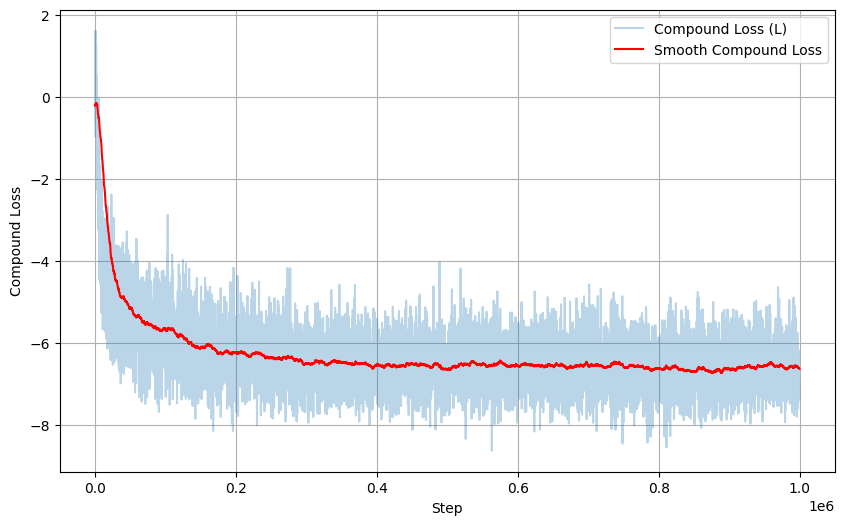

In [ ]:
plot_original_data(log_file, 'loss_square')

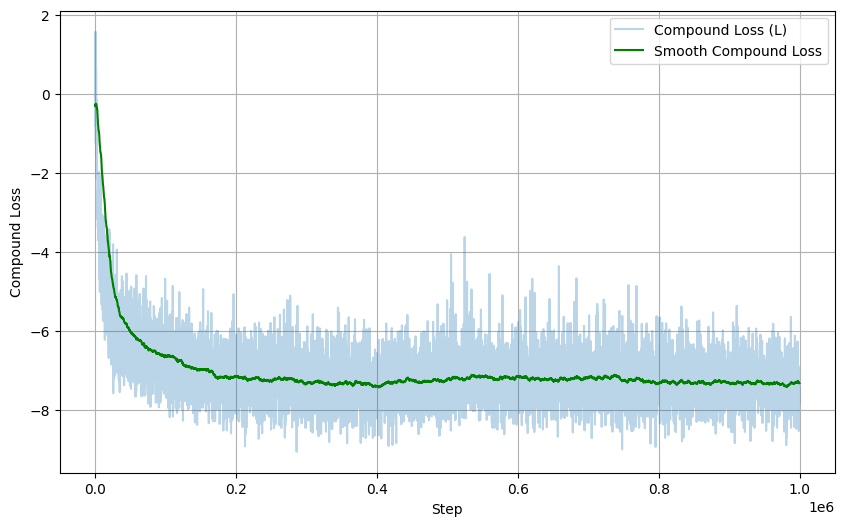

In [ ]:
plot_original_data(log_file2, 'loss_square')

* Smoothed data

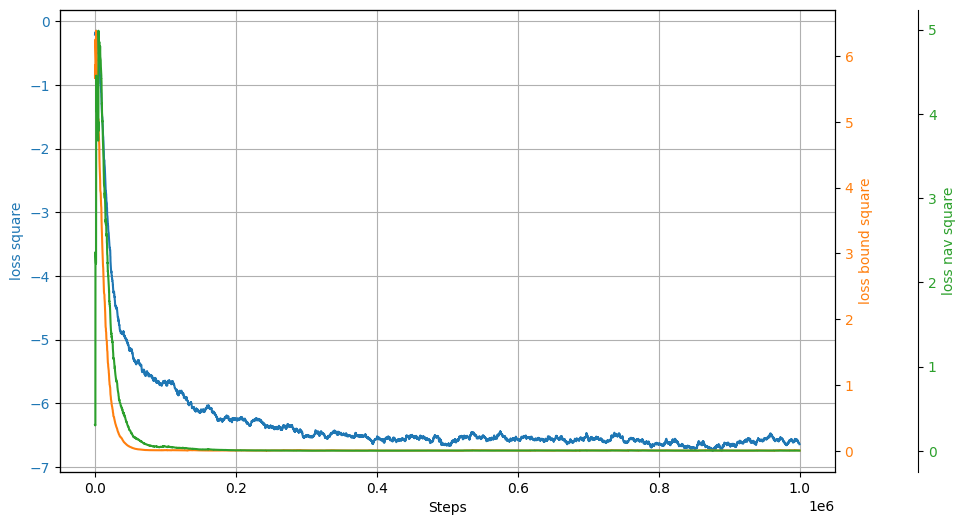

In [ ]:
plot_data(log_file, weight=0.99)

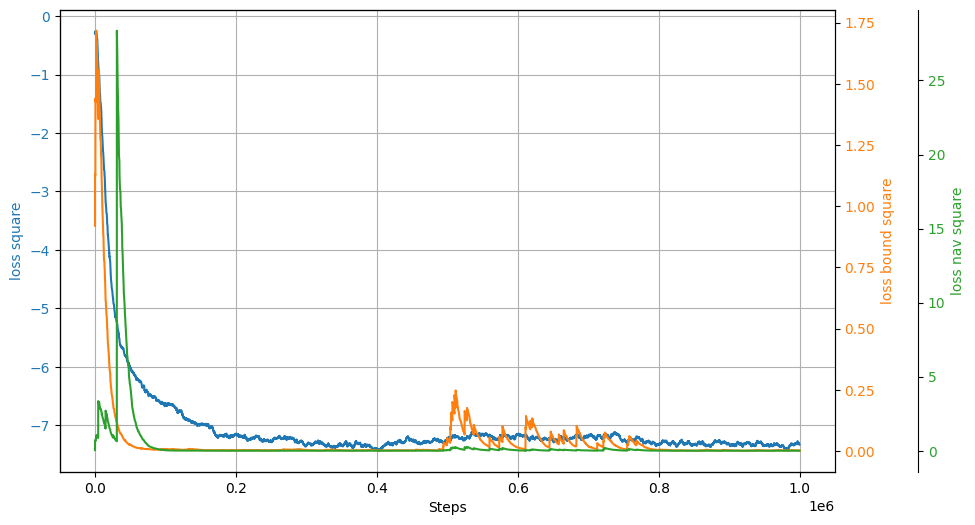

In [ ]:
plot_data(log_file2, weight=0.99)

In [ ]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def smooth_data(data, weight=0.6):
    """Applies exponential smoothing to the data."""
    smoothed = []
    last = data[0]
    for point in data:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

def plot_data2(log_file, weight=0.6):
    # Cargar los eventos del archivo de log
    event_acc = EventAccumulator(log_file)
    event_acc.Reload()

    # Extraer las tags de los scalars
    tags = event_acc.Tags()['scalars']

    # Crear la figura principal
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Colores para diferenciar cada gráfica
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    # Iterar sobre las tags y crear un gráfico para cada una
    axes = [ax1]  # Mantener una lista de los ejes para facilitar las leyendas

    for i, tag in enumerate(tags):

        # Extraer los eventos para la tag seleccionada
        scalar_events = event_acc.Scalars(tag)

        # Extraer los valores escalares
        steps = [event.step for event in scalar_events]
        values = [event.value for event in scalar_events]

        # Aplicar el suavizado a los datos
        smooth_values = smooth_data(values, weight)

        # El primer gráfico usa ax1, los siguientes usarán twinx()
        if i == 0:
            ax = ax1
        else:
            # Crear un nuevo eje y que comparte el eje x
            ax = ax1.twinx()
            ax.spines['right'].set_position(('outward', 60 * (i - 1)))  # Mover el eje hacia la derecha
            axes.append(ax)  # Agregar el nuevo eje a la lista

        # Graficar los valores suavizados
        ax.plot(steps, smooth_values, label=f'Smoothed {tag}', color=colors[i])

        # Etiquetas del eje y y estilo
        ax.set_ylabel(tag.replace('_', ' '), color=colors[i])
        ax.tick_params(axis='y', labelcolor=colors[i])

    # Etiqueta para el eje x (Steps)
    ax1.set_xlabel('Steps')

    # Añadir una cuadrícula
    ax1.grid()

    # Añadir las leyendas para cada gráfico en posiciones específicas
    ax1.legend(loc='upper left')  # Leyenda para ax1
    if len(axes) > 1:
        axes[1].legend(loc='upper center')  # Leyenda para ax2
    if len(axes) > 2:
        axes[2].legend(loc='upper right')  # Leyenda para ax3 (si existe)

    # Mostrar la gráfica
    plt.show()


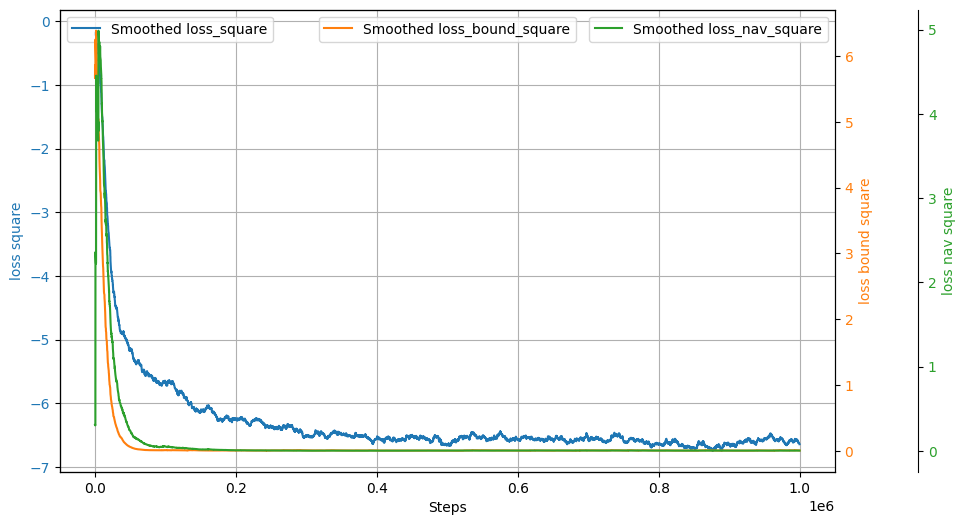

In [ ]:
plot_data2(log_file, weight=0.99)

In [ ]:
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def smooth_data(data, weight=0.6):
    """Applies exponential smoothing to the data."""
    smoothed = []
    last = data[0]
    for point in data:
        smoothed_val = last * weight + (1 - weight) * point
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

def plot_data3(log_file, weight=0.6):
    # Cargar los eventos del archivo de log
    event_acc = EventAccumulator(log_file)
    event_acc.Reload()

    # Extraer las tags de los scalars
    tags = event_acc.Tags()['scalars']

    # Crear la figura principal
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Colores para diferenciar cada gráfica
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    # Iterar sobre las tags y crear un gráfico para cada una
    axes = [ax1]  # Mantener una lista de los ejes para facilitar las leyendas

    for i, tag in enumerate(tags):

        # Extraer los eventos para la tag seleccionada
        scalar_events = event_acc.Scalars(tag)

        # Extraer los valores escalares
        steps = [event.step for event in scalar_events]
        values = [event.value for event in scalar_events]

        # Aplicar el suavizado a los datos
        smooth_values = smooth_data(values, weight)

        # El primer gráfico usa ax1, los siguientes usarán twinx()
        if i == 0:
            ax = ax1
        else:
            # Crear un nuevo eje y que comparte el eje x
            ax = ax1.twinx()
            ax.spines['right'].set_position(('outward', 30 * (i - 1)))  # Mover el eje hacia la derecha
            axes.append(ax)  # Agregar el nuevo eje a la lista

        # Graficar los valores suavizados
        tag = tag.replace('_', ' ').capitalize()
        ax.plot(steps, smooth_values, label=f'{tag}', color=colors[i])

        # Mostrar solo la escala (números) del eje y sin la etiqueta de la variable
        ax.tick_params(axis='y', labelcolor=colors[i])

    # Etiqueta para el eje x (Steps)
    ax1.set_xlabel('Steps')

    # Añadir una cuadrícula
    ax1.grid()

    # Añadir las leyendas para cada gráfico en posiciones específicas
    ax1.legend(loc='upper left')  # Leyenda para ax1
    if len(axes) > 1:
        axes[1].legend(loc='upper center')  # Leyenda para ax2
    if len(axes) > 2:
        axes[2].legend(loc='upper right')  # Leyenda para ax3 (si existe)

    # Mostrar la gráfica
    plt.show()


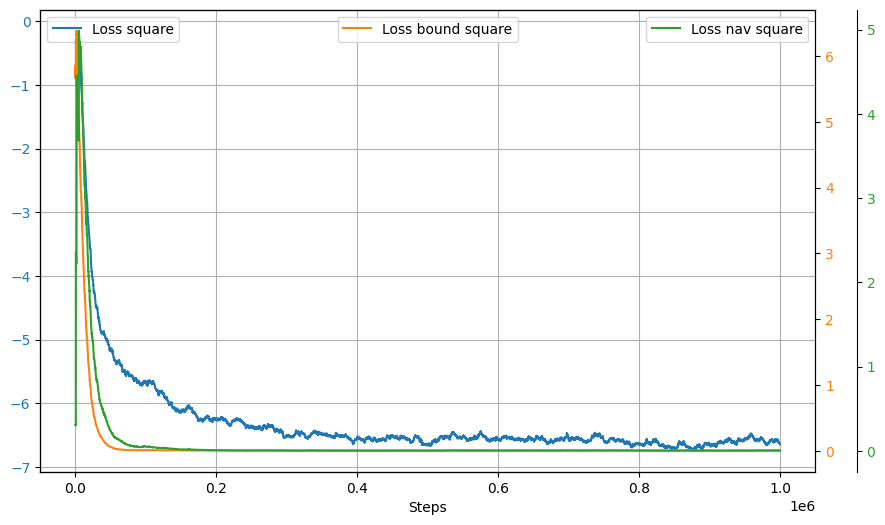

In [ ]:
plot_data3(log_file, weight=0.99)

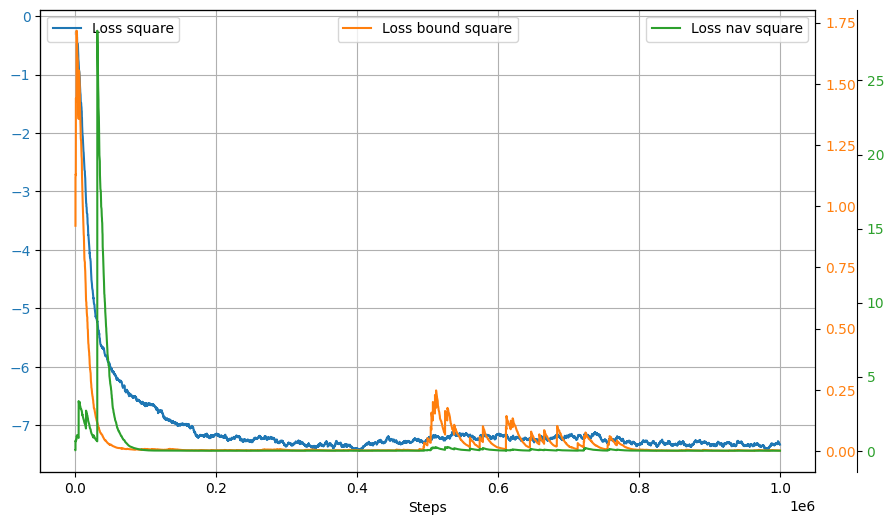

In [ ]:
plot_data3(log_file2, weight=0.99)

In [ ]:
def plot_data_4(log_file, weight=0.6, outward = 40):
    # Cargar los eventos del archivo de log
    event_acc = EventAccumulator(log_file)
    event_acc.Reload()

    # Extraer las tags de los scalars
    tags = event_acc.Tags()['scalars']

    # Crear la figura principal
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Colores para diferenciar cada gráfica
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

    # Iterar sobre las tags y crear un gráfico para cada una
    axes = [ax1]  # Mantener una lista de los ejes para facilitar las leyendas

    for i, tag in enumerate(tags):

        # Extraer los eventos para la tag seleccionada
        scalar_events = event_acc.Scalars(tag)

        # Extraer los valores escalares
        steps = [event.step for event in scalar_events]
        values = [event.value for event in scalar_events]

        # Aplicar el suavizado a los datos
        smooth_values = smooth_data(values, weight)

        # El primer gráfico usa ax1, los siguientes usarán twinx()
        if i == 0:
            ax = ax1
        else:
            # Crear un nuevo eje y que comparte el eje x
            ax = ax1.twinx()
            ax.spines['right'].set_position(('outward', outward * (i - 1)))  # Mover el eje hacia la derecha
            axes.append(ax)  # Agregar el nuevo eje a la lista


        if tag == "loss_square":
            tag = "Compound Loss (L)"
        elif tag == "loss_bound_square":
            tag = "Bound Loss (Lb)"
        elif tag == "loss_nav_square":
            tag = "Nav Loss (Lp)"
        else:
            tag = tag.replace('_', ' ').capitalize()

        # Graficar los valores suavizados
        ax.plot(steps, smooth_values, label=f'Smoothed {tag}', color=colors[i])

        # Mostrar solo la escala (números) del eje y sin la etiqueta de la variable
        ax.tick_params(axis='y', labelcolor=colors[i])

        # Colocar la leyenda en la parte superior derecha, una debajo de la otra
        ax.legend(loc='upper right', bbox_to_anchor=(1, 1 - 0.1 * i))

    # Etiqueta para el eje x (Steps)
    ax1.set_xlabel('Steps')

    # Añadir una cuadrícula
    ax1.grid()

    # Mostrar la gráfica
    plt.show()


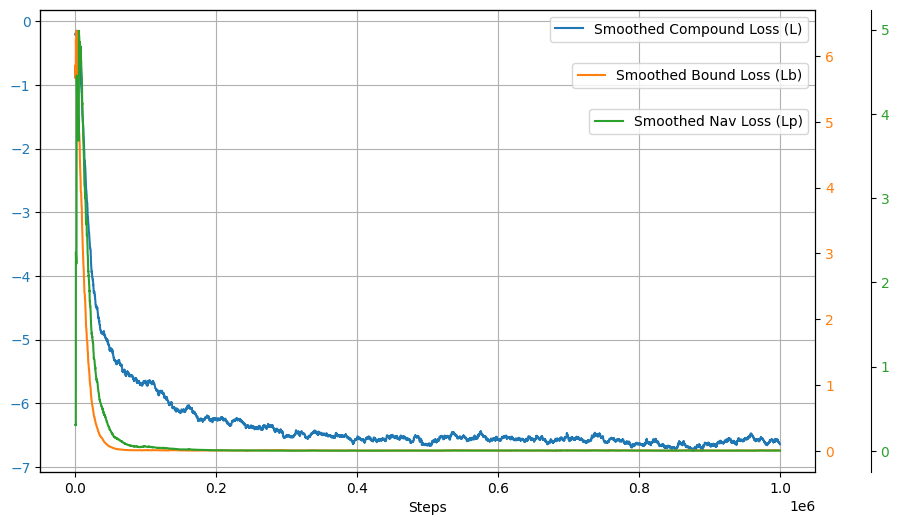

In [ ]:
plot_data_4(log_file, weight=0.99)

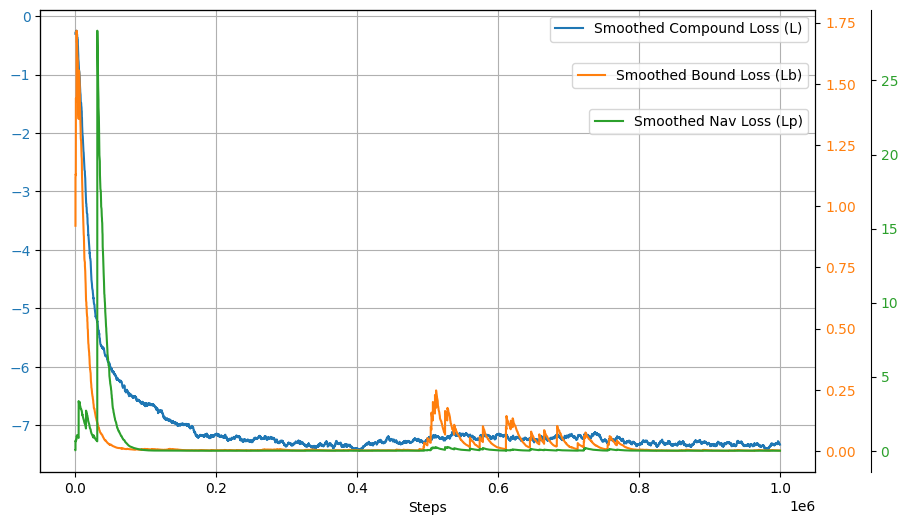

In [ ]:
plot_data_4(log_file2, weight=0.99)